In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

print("Libraries imported!")

Libraries imported!


In [2]:
df = pd.read_csv('loan-approval-predictor/loan_data.csv.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (614, 13)

First 5 rows:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
print("Missing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

Missing Values:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Data Types:
Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object


In [4]:
# Loan_ID drop karo
df.drop('Loan_ID', axis=1, inplace=True)

# Missing values fill karo
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


C:\Users\Asus\AppData\Local\Temp\ipykernel_27636\489440980.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
C:\Users\Asus\AppData\Local\Temp\ipykernel_27636\489440980.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

Fo

In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cols = ['Gender', 'Married', 'Dependents', 'Education', 
        'Self_Employed', 'Property_Area', 'Loan_Status']

for col in cols:
    df[col] = le.fit_transform(df[col])

print("Encoding done!")
print(df.head())

Encoding done!
   Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0       1        0           0          0              0             5849   
1       1        1           1          0              0             4583   
2       1        1           0          0              1             3000   
3       1        1           0          1              0             2583   
4       1        0           0          0              0             6000   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                0.0       128.0             360.0             1.0   
1             1508.0       128.0             360.0             1.0   
2                0.0        66.0             360.0             1.0   
3             2358.0       120.0             360.0             1.0   
4                0.0       141.0             360.0             1.0   

   Property_Area  Loan_Status  
0              2            1  
1              0            0  
2    

In [6]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (491, 11)
X_test shape: (123, 11)


In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("=== Decision Tree ===")
print("Accuracy:", round(accuracy_score(y_test, dt_pred) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, dt_pred))

=== Decision Tree ===
Accuracy: 74.8 %

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.44      0.55        43
           1       0.75      0.91      0.82        80

    accuracy                           0.75       123
   macro avg       0.74      0.68      0.69       123
weighted avg       0.74      0.75      0.73       123



In [8]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("=== Random Forest ===")
print("Accuracy:", round(accuracy_score(y_test, rf_pred) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

=== Random Forest ===
Accuracy: 75.61 %

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.42      0.55        43
           1       0.75      0.94      0.83        80

    accuracy                           0.76       123
   macro avg       0.77      0.68      0.69       123
weighted avg       0.76      0.76      0.73       123



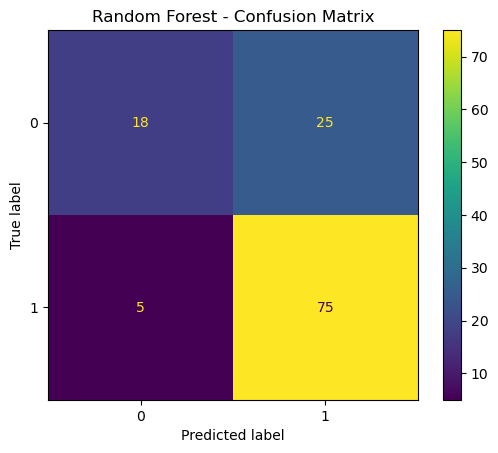

In [9]:
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred)
plt.title("Random Forest - Confusion Matrix")
plt.show()

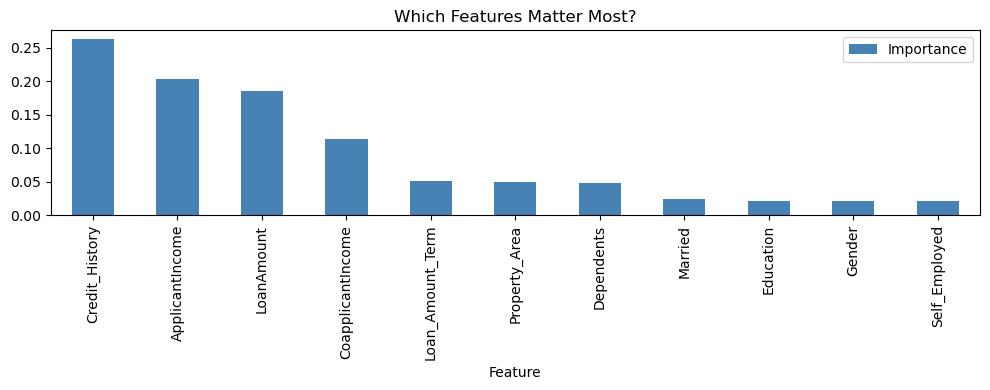

In [10]:
importances = rf_model.feature_importances_
feat_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False)

feat_df.plot(kind='bar', x='Feature', y='Importance', 
             color='steelblue', figsize=(10,4))
plt.title("Which Features Matter Most?")
plt.tight_layout()
plt.show()

C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

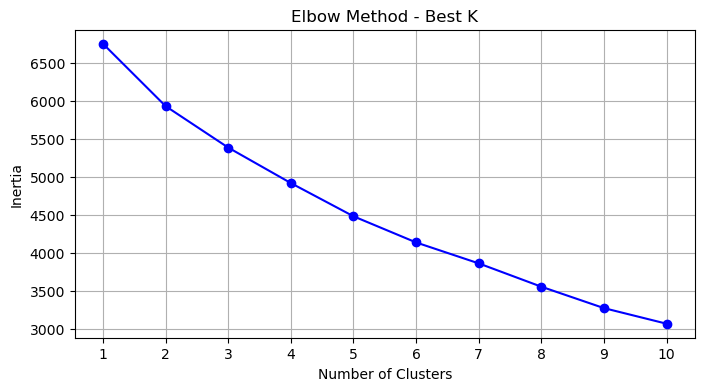

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), inertia, marker='o', color='blue')
plt.title('Elbow Method - Best K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


Cluster Distribution:
Risk_Segment
Low Risk       322
Medium Risk    200
High Risk       92
Name: count, dtype: int64


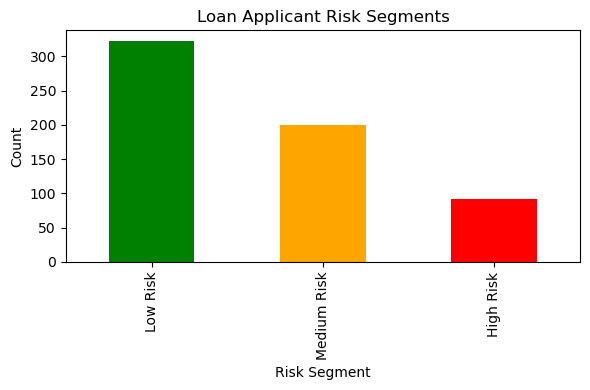

In [12]:
km_model = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Risk_Segment'] = km_model.fit_predict(X_scaled)

df['Risk_Segment'] = df['Risk_Segment'].map({
    0: 'Low Risk',
    1: 'Medium Risk', 
    2: 'High Risk'
})

print("Cluster Distribution:")
print(df['Risk_Segment'].value_counts())

plt.figure(figsize=(6, 4))
df['Risk_Segment'].value_counts().plot(kind='bar', 
    color=['green', 'orange', 'red'])
plt.title('Loan Applicant Risk Segments')
plt.xlabel('Risk Segment')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [15]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [16]:
import pickle

# Model save karo
with open('rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

# Scaler save karo
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model saved!")

Model saved!


In [17]:
import pickle
import os

path = r'C:\Users\Asus\loan-approval-predictor'

with open(os.path.join(path, 'rf_model.pkl'), 'wb') as f:
    pickle.dump(rf_model, f)

print("Model saved!")

Model saved!


In [18]:
import pandas as pd
import numpy as np
import pickle
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Dataset load
df = pd.read_csv(r'C:\Users\Asus\loan-approval-predictor\loan_data.csv.csv')

# Cleaning
df.drop('Loan_ID', axis=1, inplace=True)
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

# Encoding
le = LabelEncoder()
cols = ['Gender', 'Married', 'Dependents', 'Education', 
        'Self_Employed', 'Property_Area', 'Loan_Status']
for col in cols:
    df[col] = le.fit_transform(df[col])

# Train Test Split
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Model train
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Save model
path = r'C:\Users\Asus\loan-approval-predictor'
with open(os.path.join(path, 'rf_model.pkl'), 'wb') as f:
    pickle.dump(rf_model, f)

print("✅ Model saved successfully!")

✅ Model saved successfully!


C:\Users\Asus\AppData\Local\Temp\ipykernel_27636\1776331049.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
C:\Users\Asus\AppData\Local\Temp\ipykernel_27636\1776331049.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.